# Fixed Cell Cycle Volume Comparison

Reproduce the fixed cell-cycle volume comparison across BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim, with experimental reference data. Simulation volumes are shown as a percentage of each tool's initial volume.

## Step 1: Import Required Libraries

Use only the libraries needed for data loading, path handling, validation, and plotting.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Step 2: Define Repository Paths and Output Folders

Keep each source path explicit so the inputs can be changed independently. The paths below follow the current repository locations.

In [ ]:
ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / 'ResultAnalysis').is_dir()),
    Path.cwd(),
)

PHYSICELL_CSV = ROOT / 'PhysiCell' / 'results' / 'cell_cycle_fixed' / 'cell_volumes.csv'
BIODYNAMO_CSV = ROOT / 'Biodynamo' / 'fixed_cell_cycle' / 'new_results' / 'cell-0-sim1.csv'
CHASTE_DAT = ROOT / 'Chaste' / 'fixed_cell_cycle' / 'results' / 'cellcycle_fixed.dat'
TISIM_CSV = ROOT / 'Tisim' / 'fixed_cell_cycle' / 'cell cycle fix.csv'
COMPUTIX_CSV = ROOT / 'CompuTiX' / 'fixed_cell_cycle' / 'data' / 'cell_cycle.csv'
EXPERIMENTAL_TXT = ROOT / 'ResultAnalysis' / 'analytical_solutions' / 'experimental_data' / 'Cell cycle volume dynamics.txt'

OUTPUT_DIR = ROOT / 'ResultAnalysis' / 'plots' / 'cell_cycle_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_PATHS = {
    'PhysiCell': PHYSICELL_CSV,
    'BioDynaMo': BIODYNAMO_CSV,
    'Chaste': CHASTE_DAT,
    'TiSim': TISIM_CSV,
    'CompuTiX': COMPUTIX_CSV,
    'Reference Data': EXPERIMENTAL_TXT,
}

missing_paths = [path for path in INPUT_PATHS.values() if not path.is_file()]
if missing_paths:
    raise FileNotFoundError('Missing input file(s):\n' + '\n'.join(map(str, missing_paths)))

print(f'Repository root: {ROOT}')
print(f'Plot output directory: {OUTPUT_DIR}')

Repository root: /home/tntiniak/Work/observatory_benchmark
Plot output directory: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/cell_cycle_plots


## Step 3: Set Shared Plotting Style and Reuse the Decay Color Palette

The simulator colors match the decay comparison. Experimental reference data is black; all simulator series use solid lines and the reference uses a dotted line.

In [3]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 2.0,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi': 400,
})

TOOL_COLORS = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'CompuTiX': '#fd2a2a',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
    'Reference Data': '#000000',
}

LINESTYLES = {tool: '-' for tool in TOOL_COLORS}
LINESTYLES['Reference Data'] = 'dotted'

LEGEND_LABELS = {tool: tool for tool in TOOL_COLORS}

## Step 4: Load All Tool Outputs in One Cell and Standardize Columns

Load each result once into the same raw schema. Chaste stores one or more 11-field cell records after each timestep; TiSim is averaged across its cell-volume columns, while CompuTiX and the experimental reference already provide relative-volume percentages.

In [4]:
frames = {}

pc_source = pd.read_csv(PHYSICELL_CSV, float_precision='round_trip')
frames['PhysiCell'] = pd.DataFrame({
    'tool': 'PhysiCell',
    'time_value': pd.to_numeric(pc_source['dt']),
    'time_unit': 'minutes',
    'volume_value': pd.to_numeric(pc_source['total_volume']),
    'volume_unit': 'absolute',
    'run_id': 'PhysiCell_fixed_cell_cycle',
})

bd_source = pd.read_csv(
    BIODYNAMO_CSV,
    header=None,
    names=['timestep', 'volume', 'phase', 'age'],
)
frames['BioDynaMo'] = pd.DataFrame({
    'tool': 'BioDynaMo',
    'time_value': pd.to_numeric(bd_source['timestep']),
    'time_unit': 'hours',
    'volume_value': pd.to_numeric(bd_source['volume']),
    'volume_unit': 'absolute',
    'run_id': 'BioDynaMo_fixed_cell_cycle',
})

chaste_records = []
for line_number, line in enumerate(CHASTE_DAT.read_text().splitlines(), start=1):
    fields = line.split()
    if not fields:
        continue
    time_h = float(fields[0])
    cell_fields = fields[1:]
    if len(cell_fields) % 11 != 0:
        raise ValueError(f'{CHASTE_DAT.name}, line {line_number}: expected 11 fields per cell record.')
    for offset in range(0, len(cell_fields), 11):
        cell_record = cell_fields[offset:offset + 11]
        chaste_records.append({
            'tool': 'Chaste',
            'time_value': time_h,
            'time_unit': 'hours',
            'volume_value': float(cell_record[10]),
            'volume_unit': 'absolute',
            'run_id': 'Chaste_fixed_cell_cycle',
        })
frames['Chaste'] = pd.DataFrame(chaste_records)

tisim_source = pd.read_csv(TISIM_CSV)
tisim_volume_columns = tisim_source.columns[1:]
tisim_average = tisim_source[tisim_volume_columns].mean(axis=1, skipna=True)
frames['TiSim'] = pd.DataFrame({
    'tool': 'TiSim',
    'time_value': pd.to_numeric(tisim_source['time (hour)']),
    'time_unit': 'hours',
    'volume_value': tisim_average,
    'volume_unit': 'absolute',
    'run_id': 'TiSim_fixed_cell_cycle',
})

computix_source = pd.read_csv(COMPUTIX_CSV)
frames['CompuTiX'] = pd.DataFrame({
    'tool': 'CompuTiX',
    'time_value': pd.to_numeric(computix_source['#Time (minutes)']),
    'time_unit': 'minutes',
    'volume_value': pd.to_numeric(computix_source['relative_volume']),
    'volume_unit': 'percent',
    'run_id': 'CompuTiX_fixed_cell_cycle',
})

experimental_source = pd.read_csv(EXPERIMENTAL_TXT, sep='\t')
frames['Reference Data'] = pd.DataFrame({
    'tool': 'Reference Data',
    'time_value': pd.to_numeric(experimental_source['Hours']),
    'time_unit': 'hours',
    'volume_value': pd.to_numeric(experimental_source['relative_volume']),
    'volume_unit': 'percent',
    'run_id': 'Experimental_reference',
})

raw_comparison = pd.concat(frames.values(), ignore_index=True)
raw_comparison

,tool,time_value,time_unit,volume_value,volume_unit,run_id
0,PhysiCell,0.0,minutes,523.600000,absolute,PhysiCell_fixed_cell_cycle
1,PhysiCell,30.0,minutes,523.600000,absolute,PhysiCell_fixed_cell_cycle
2,PhysiCell,60.0,minutes,523.600000,absolute,PhysiCell_fixed_cell_cycle
3,PhysiCell,90.0,minutes,523.600000,absolute,PhysiCell_fixed_cell_cycle
4,PhysiCell,120.0,minutes,523.600000,absolute,PhysiCell_fixed_cell_cycle
...,...,...,...,...,...,...
6172,Reference Data,22.0,hours,99.720611,percent,Experimental_reference
6173,Reference Data,22.5,hours,99.720611,percent,Experimental_reference
6174,Reference Data,23.0,hours,99.773817,percent,Experimental_reference
6175,Reference Data,23.5,hours,99.773817,percent,Experimental_reference


## Step 5: Normalize Time and Volume Metrics Across Tools

Convert minute-based PhysiCell and CompuTiX timestamps to hours. Average multiple volumes recorded at the same time, then scale absolute-volume simulator data by its first-time-point mean. CompuTiX and experimental relative volumes are retained as percentages.

In [5]:
normalized_frames = []

for tool, source_frame in frames.items():
    frame = source_frame.copy()
    frame['time_h'] = np.where(
        frame['time_unit'].eq('minutes'),
        frame['time_value'] / 60.0,
        frame['time_value'],
    )
    grouped = (
        frame.groupby(['tool', 'run_id', 'time_h', 'volume_unit'], as_index=False)
        ['volume_value']
        .mean()
        .sort_values('time_h')
        .reset_index(drop=True)
    )

    if grouped['volume_unit'].nunique() != 1:
        raise ValueError(f'{tool}: expected one volume unit per series.')
    if grouped['volume_unit'].iloc[0] == 'percent':
        grouped['volume_percent'] = grouped['volume_value']
    else:
        initial_volume = grouped['volume_value'].iloc[0]
        if not np.isfinite(initial_volume) or initial_volume == 0:
            raise ValueError(f'{tool}: initial volume must be finite and non-zero.')
        grouped['volume_percent'] = grouped['volume_value'] / initial_volume * 100.0

    normalized_frames.append(
        grouped[['tool', 'run_id', 'time_h', 'volume_percent']]
    )

normalized_comparison = pd.concat(normalized_frames, ignore_index=True)
normalized_comparison

,tool,run_id,time_h,volume_percent
0,PhysiCell,PhysiCell_fixed_cell_cycle,0.0,100.000000
1,PhysiCell,PhysiCell_fixed_cell_cycle,0.5,100.000000
2,PhysiCell,PhysiCell_fixed_cell_cycle,1.0,100.000000
3,PhysiCell,PhysiCell_fixed_cell_cycle,1.5,100.000000
4,PhysiCell,PhysiCell_fixed_cell_cycle,2.0,100.000000
...,...,...,...,...
5521,Reference Data,Experimental_reference,22.0,99.720611
5522,Reference Data,Experimental_reference,22.5,99.720611
5523,Reference Data,Experimental_reference,23.0,99.773817
5524,Reference Data,Experimental_reference,23.5,99.773817


## Step 6: Assemble a Unified Comparison Table and Run Validation Checks

The long-form table has one row per tool and time point. Confirm all expected series are present and that time and normalized volume values are finite and ordered.

In [6]:
comparison_table = normalized_comparison.sort_values(
    ['tool', 'time_h'],
    ignore_index=True,
)
expected_tools = set(TOOL_COLORS)
assert set(comparison_table['tool']) == expected_tools
assert np.isfinite(comparison_table[['time_h', 'volume_percent']].to_numpy()).all()
assert not comparison_table.duplicated(['tool', 'run_id', 'time_h']).any()

for tool, series in comparison_table.groupby('tool', sort=False):
    assert not series.empty, f'{tool}: no samples were loaded.'
    assert series['time_h'].is_monotonic_increasing, f'{tool}: time is not monotonic.'

series_summary = (
    comparison_table.groupby('tool', sort=False)
    .agg(
        sample_count=('time_h', 'size'),
        first_time_h=('time_h', 'min'),
        last_time_h=('time_h', 'max'),
        minimum_volume_percent=('volume_percent', 'min'),
        maximum_volume_percent=('volume_percent', 'max'),
    )
    .reset_index()
)
series_summary

,tool,sample_count,first_time_h,last_time_h,minimum_volume_percent,maximum_volume_percent
0,BioDynaMo,4800,0.01,48.0,99.703972,199.733002
1,Chaste,481,0.00,48.0,99.690603,200.959131
2,CompuTiX,49,0.00,24.0,99.348251,200.335247
3,PhysiCell,97,0.00,48.0,99.360529,198.418989
4,Reference Data,49,0.00,24.0,99.348251,200.335247
5,TiSim,50,1.00,50.0,100.000000,198.518000


## Step 7: Create the Fixed Cell Cycle Volume Plot With Phase Boundaries

Plot normalized simulator volumes and the experimental reference, then annotate the three repeated 18-hour cell-cycle phase blocks.

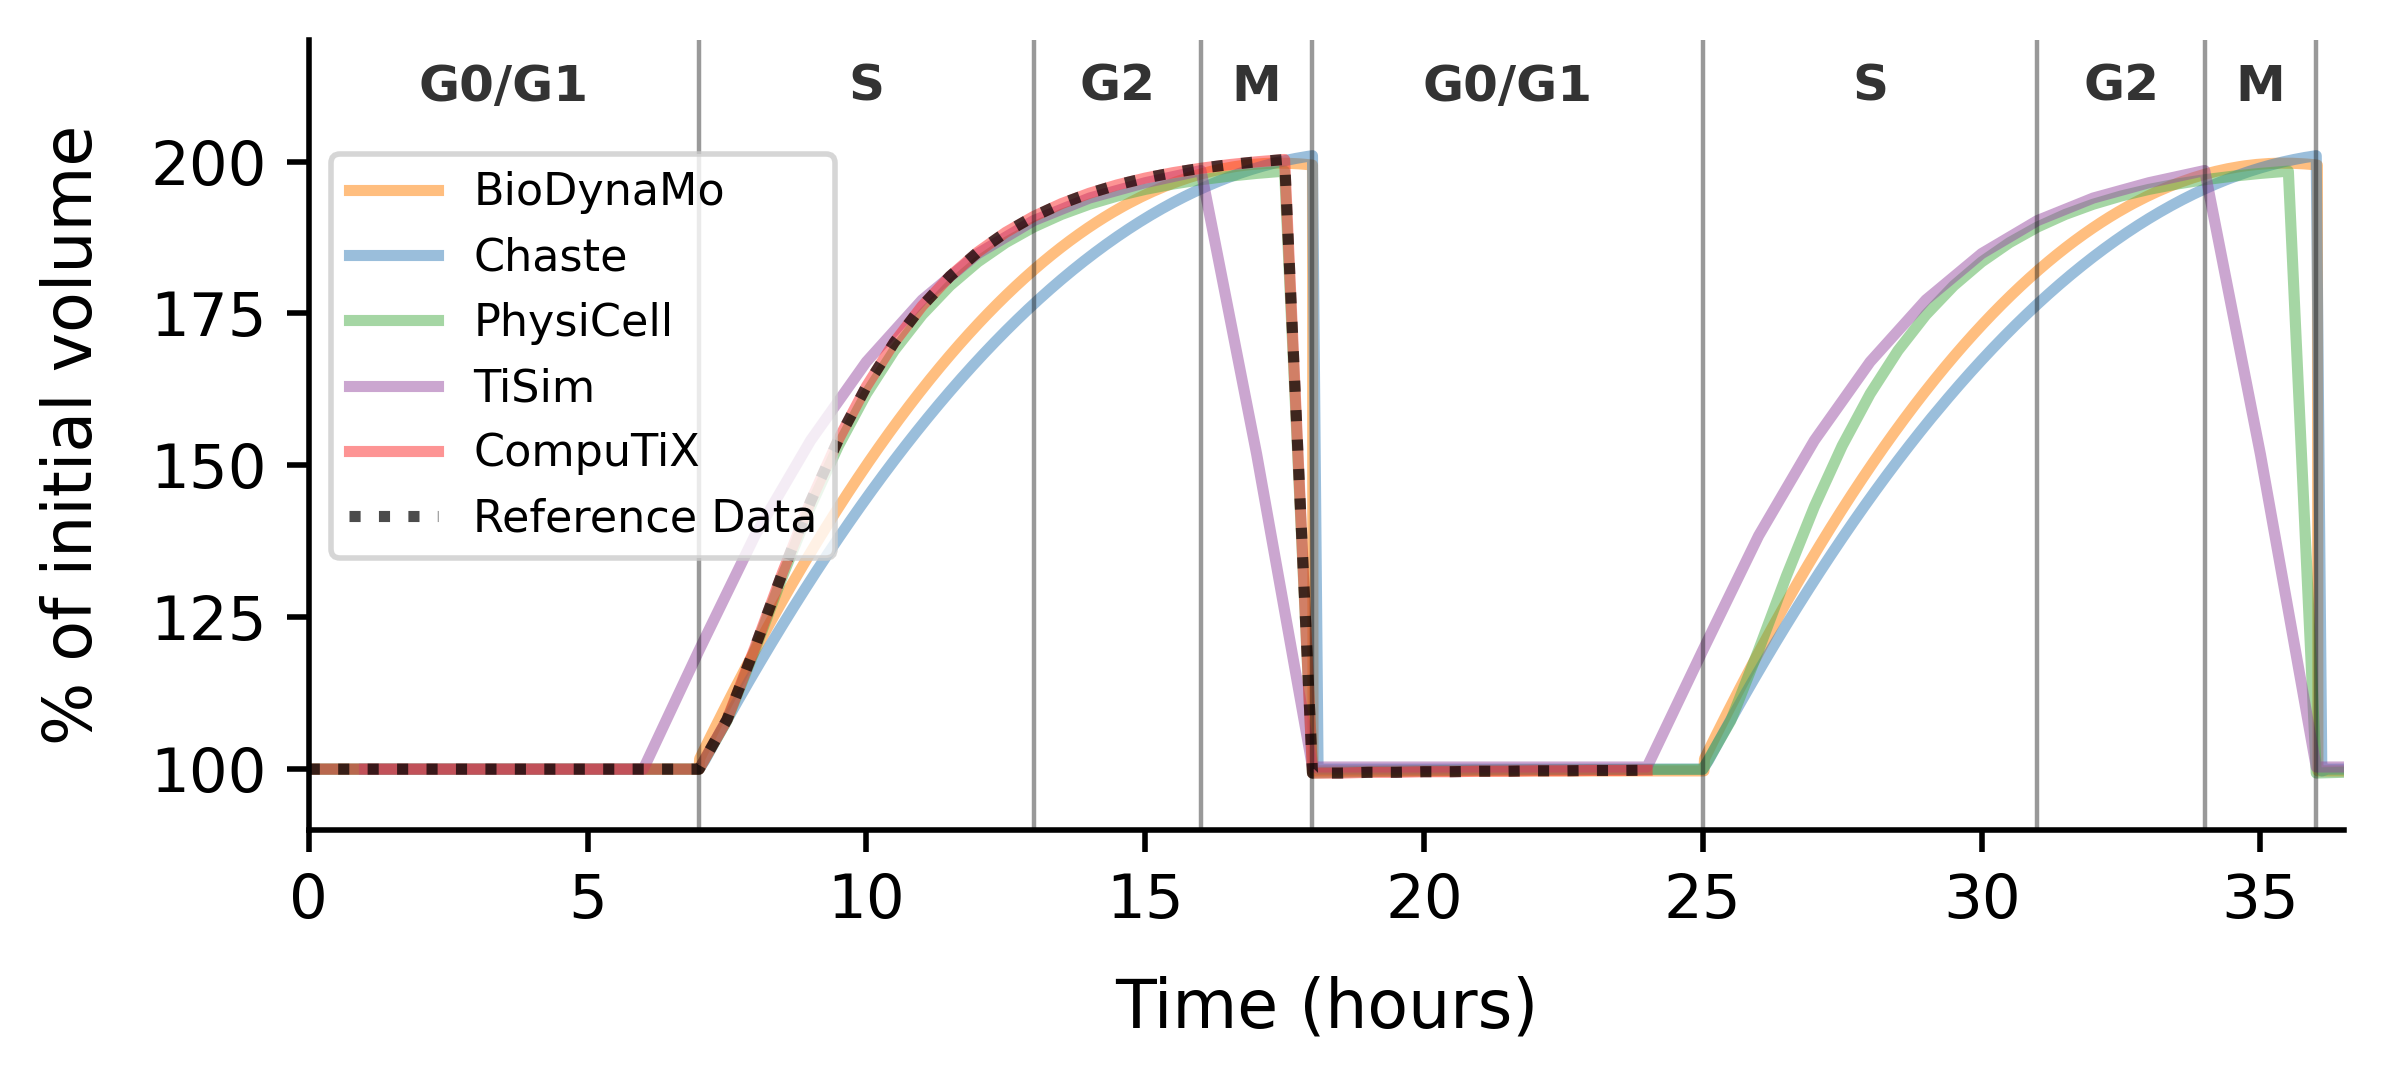

In [7]:
simulator_order = ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim', 'CompuTiX']
fig, ax = plt.subplots(figsize=(6, 2.8))

for tool in simulator_order:
    series = comparison_table.loc[comparison_table['tool'] == tool]
    ax.plot(
        series['time_h'],
        series['volume_percent'],
        color=TOOL_COLORS[tool],
        linestyle=LINESTYLES[tool],
        label=LEGEND_LABELS[tool],
        linewidth=2.0,
        alpha=0.5,
    )

reference = comparison_table.loc[comparison_table['tool'] == 'Reference Data']
ax.plot(
    reference['time_h'],
    reference['volume_percent'],
    color=TOOL_COLORS['Reference Data'],
    linestyle=LINESTYLES['Reference Data'],
    label=LEGEND_LABELS['Reference Data'],
    linewidth=2.0,
    alpha=0.7,
)

for cycle in range(3):
    base = 18 * cycle
    phases = [
        (base, 7, 'G0/G1'),
        (base + 7, 6, 'S'),
        (base + 13, 3, 'G2'),
        (base + 16, 2, 'M'),
    ]
    for start, duration, phase_label in phases:
        if start + duration <= 36:
            ax.text(
                start + duration / 2,
                210,
                phase_label,
                color='black',
                alpha=0.8,
                fontsize=9,
                ha='center',
                fontweight='bold',
            )
            ax.axvline(
                x=start + duration,
                color='black',
                linestyle='-',
                linewidth=0.8,
                alpha=0.4,
            )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(loc='center left', bbox_to_anchor=(0, 0.6), fontsize=8)
ax.set_xlim(0, 36.5)
ax.set_ylim(90, 220)
ax.set_xlabel('Time (hours)', labelpad=8, fontsize=12)
ax.set_ylabel('% of initial volume', labelpad=8, fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=11)
fig.tight_layout()

## Step 8: Export the Figure to `ResultAnalysis/plots/cell_cycle_plots`

Save a high-resolution PNG and a vector SVG using a tight bounding box.

In [8]:
png_path = OUTPUT_DIR / 'fixed_cell_cycle_volumes.png'
svg_path = OUTPUT_DIR / 'fixed_cell_cycle_volumes.svg'

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches='tight',
    pad_inches=0.1,
    format='png',
)
fig.savefig(
    svg_path,
    bbox_inches='tight',
    pad_inches=0.1,
    format='svg',
)

plt.show()
plt.close(fig)

print(f'Saved PNG: {png_path}')
print(f'Saved SVG: {svg_path}')

Saved PNG: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/cell_cycle_plots/fixed_cell_cycle_volumes.png
Saved SVG: /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/cell_cycle_plots/fixed_cell_cycle_volumes.svg
